In [13]:
# Setup
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "../transit.db"
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

# This helper let us run any SQL query and get a DataFrame back.
def query(sql):
    return pd.read_sql_query(sql, conn)

## Question 1 — Top 10 stations by average hourly ridership

We aggregate total ridership per station across all years and compute the
average per hour-slot to find the busiest stations in the system.

In [2]:
df_top_stations = query("""
    SELECT station_complex, SUM(ridership) AS total_ridership
    FROM ridership
    GROUP BY station_complex
    ORDER BY total_ridership DESC
    LIMIT 10;
""")

df_top_stations

,station_complex,total_ridership
0,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",168202157
1,"Grand Central-42 St (S,4,5,6,7)",115353629
2,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)",97401047
3,"14 St-Union Sq (L,N,Q,R,W,4,5,6)",86561174
4,"Fulton St (A,C,J,Z,2,3,4,5)",70686291
5,"34 St-Penn Station (A,C,E)",68310948
6,"59 St-Columbus Circle (A,B,C,D,1)",63617661
7,"34 St-Penn Station (1,2,3)",62794521
8,"74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,...",58200078
9,Flushing-Main St (7),57024065


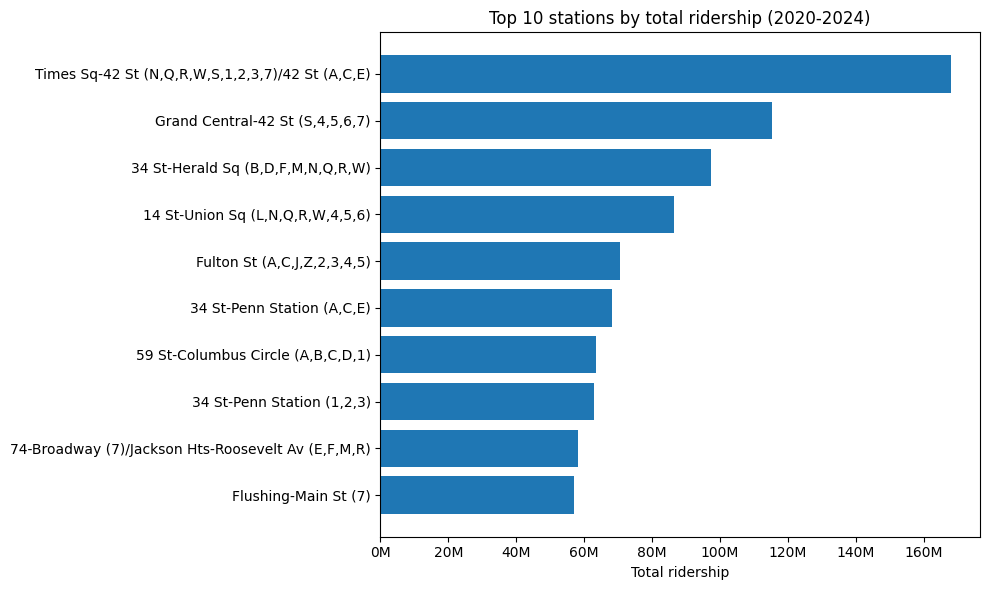

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(df_top_stations['station_complex'], df_top_stations['total_ridership'])
ax.invert_yaxis()
ax.set_title("Top 10 stations by total ridership (2020-2024)")
ax.set_xlabel("Total ridership")
ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x / 1e6:,.0f}M'))

plt.tight_layout()
plt.savefig("../report/figures/top_stations.png", dpi=150, bbox_inches="tight")
plt.show()

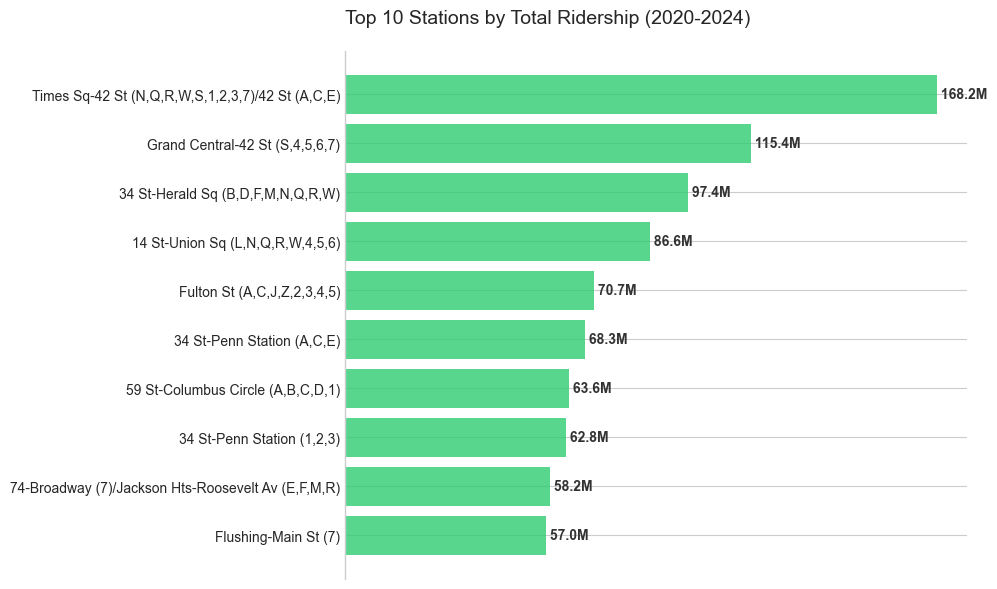

In [9]:
# 1. Set a cleaner style
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Use a specific color and add some transparency/edgecolor for polish
bars = ax.barh(df_top_stations['station_complex'], 
               df_top_stations['total_ridership'], 
               color='#2ecc71', alpha=0.8)

ax.invert_yaxis()

# 3. Add direct value labels on the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f' {width / 1e6:.1f}M', 
            va='center', fontweight='bold', color='#333333')

# 4. Clean up the "Chart Junk"
ax.set_title("Top 10 Stations by Total Ridership (2020-2024)", fontsize=14, pad=20, loc='left')
ax.set_xlabel("") # Remove xlabel because labels are on bars
ax.set_xticks([]) # Remove x-axis ticks
ax.spines[['top', 'right', 'bottom']].set_visible(False) # Despine

plt.tight_layout()
plt.savefig("../report/figures/top_stations_pro.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
df_top_2024_stations = query("""
    SELECT station_complex, SUM(ridership) AS total_ridership
    FROM ridership
    WHERE date LIKE '2024%'
    GROUP BY station_complex
    ORDER BY total_ridership DESC
    LIMIT 10;
""")

df_top_2024_stations

,station_complex,total_ridership
0,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",45944536
1,"Grand Central-42 St (S,4,5,6,7)",33982818
2,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)",25076610
3,"14 St-Union Sq (L,N,Q,R,W,4,5,6)",22946143
4,"Fulton St (A,C,J,Z,2,3,4,5)",19306850
5,"34 St-Penn Station (A,C,E)",18672456
6,"59 St-Columbus Circle (A,B,C,D,1)",17000777
7,"34 St-Penn Station (1,2,3)",16657086
8,"74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,...",15099573
9,Flushing-Main St (7),14751454


# Question 2 — Ridership by hour of day

Total ridership for each hour (0–23) across the entire dataset

In [ ]:
df_top_hour_stations = query("""
    SELECT hour, SUM(ridership) AS total_ridership
    FROM ridership
    GROUP BY hour
    ORDER BY hour ASC;
""")

df_top_hour_stations

,hour,total_ridership
0,0,40793000
1,1,16876695
2,2,9925712
3,3,9337113
4,4,23890519
5,5,85264307
6,6,182442214
7,7,324069881
8,8,379077055
9,9,263391564


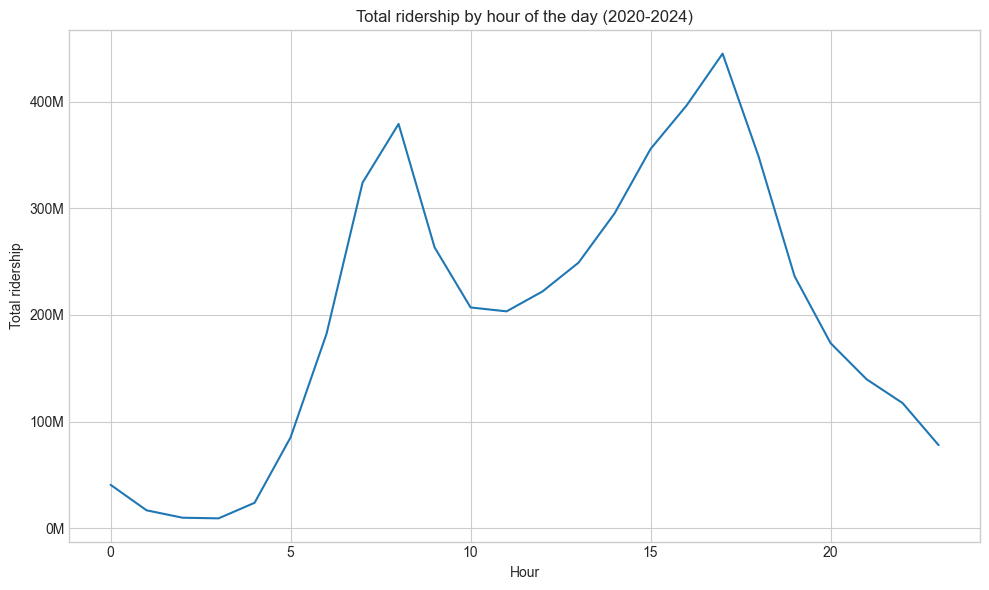

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_top_hour_stations['hour'], df_top_hour_stations['total_ridership'])
ax.set_title("Total ridership by hour of the day (2020-2024)")
ax.set_xlabel("Hour")
ax.set_ylabel("Total ridership")
ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x / 1e6:,.0f}M'))

plt.tight_layout()
plt.savefig("../report/figures/total_ridership_per_hour.png", dpi=150, 
        bbox_inches="tight")
plt.show()

In this graph we see a very clear double-peak shape: a morning rush around hour 8 and an evening rush around hour 17–18, with a valley in the early morning hours between 2–5am.

# Question 3 — Ridership by day of week

Total ridership for each day of the week across the entire dataset

In [15]:
df_top_day_stations = query("""
    SELECT day_of_week, SUM(ridership) AS total_ridership
    FROM ridership
    GROUP BY day_of_week
    ORDER BY
    CASE day_of_week
        WHEN 'Monday'    THEN 1
        WHEN 'Tuesday'   THEN 2
        WHEN 'Wednesday' THEN 3
        WHEN 'Thursday'  THEN 4
        WHEN 'Friday'    THEN 5
        WHEN 'Saturday'  THEN 6
        WHEN 'Sunday'    THEN 7
    END ASC;
""")

df_top_day_stations

,day_of_week,total_ridership
0,Monday,710620423
1,Tuesday,799152502
2,Wednesday,813351238
3,Thursday,804562678
4,Friday,765043214
5,Saturday,507751060
6,Sunday,402186392


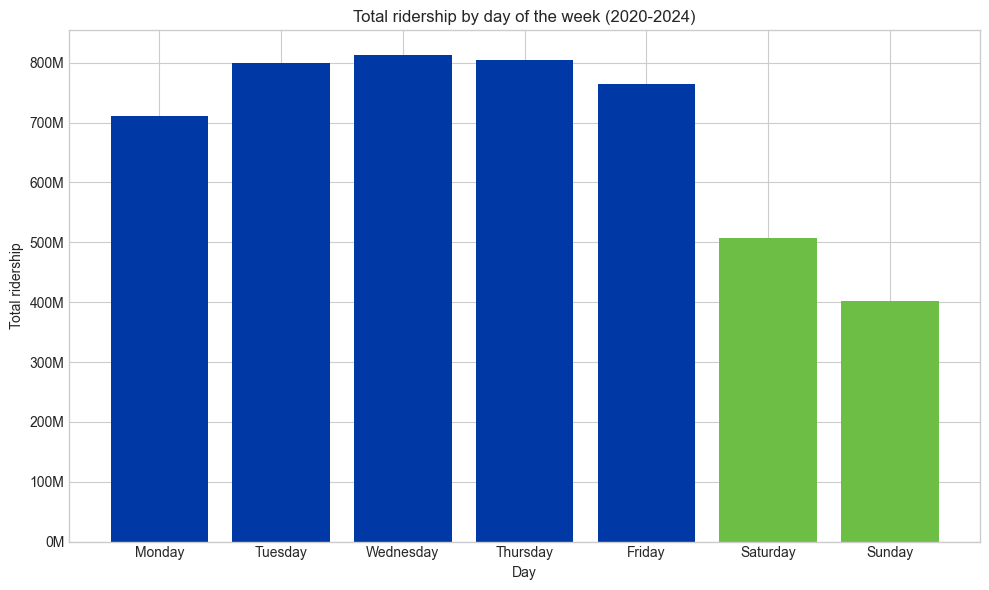

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#0039A6" if day not in ["Saturday", "Sunday"] 
          else "#6CBE45" for day in df_top_day_stations["day_of_week"]]

ax.bar(df_top_day_stations['day_of_week'],
       df_top_day_stations['total_ridership'],
       color=colors)
ax.set_title("Total ridership by day of the week (2020-2024)")
ax.set_xlabel("Day")
ax.set_ylabel("Total ridership")
ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x / 1e6:,.0f}M'))

plt.tight_layout()
plt.savefig("../report/figures/total_ridership_per_day.png", dpi=150, 
        bbox_inches="tight")
plt.show()

# Question 4 — Ridership by borough

In [4]:
df_top_borough_stations = query("""
    SELECT borough, SUM(ridership) AS total_ridership
    FROM ridership
    GROUP BY borough
    ORDER BY total_ridership DESC;
""")

df_top_borough_stations

,borough,total_ridership
0,Manhattan,2576696933
1,Brooklyn,1098173934
2,Queens,734786641
3,Bronx,384163084
4,Staten Island,8846915


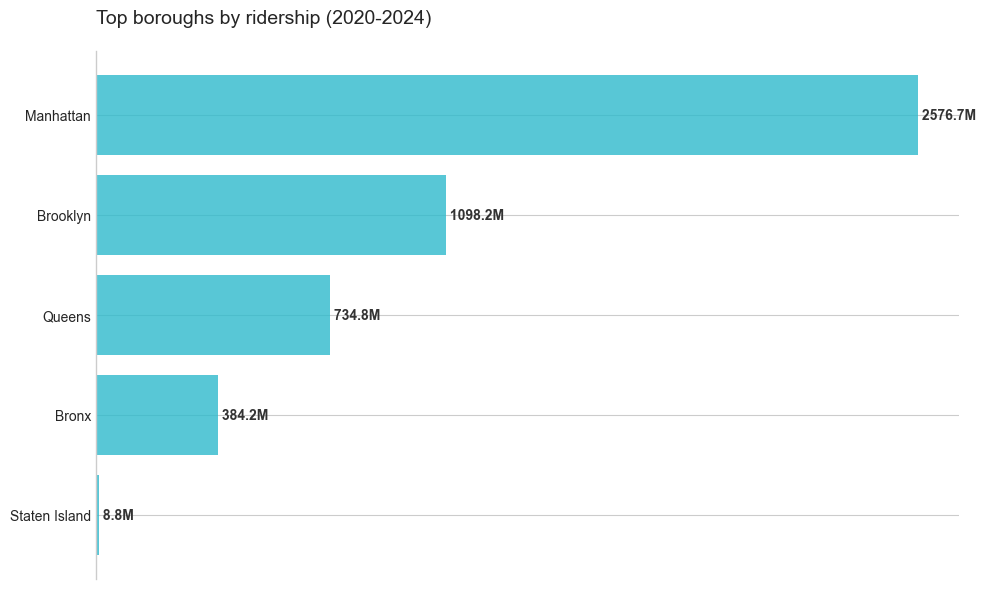

In [6]:
# 1. Set a cleaner style
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Use a specific color and add some transparency/edgecolor for polish
bars = ax.barh(df_top_borough_stations['borough'], 
               df_top_borough_stations['total_ridership'], 
               color="#2ebacc", alpha=0.8)

ax.invert_yaxis()

# 3. Add direct value labels on the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f' {width / 1e6:.1f}M', 
            va='center', fontweight='bold', color='#333333')

# 4. Clean up the "Chart Junk"
ax.set_title("Top boroughs by ridership (2020-2024)", fontsize=14, pad=20, loc='left')
ax.set_xlabel("") # Remove xlabel because labels are on bars
ax.set_xticks([]) # Remove x-axis ticks
ax.spines[['top', 'right', 'bottom']].set_visible(False) # Despine

plt.tight_layout()
plt.savefig("../report/figures/top_ridership_borough.png", dpi=150, bbox_inches="tight")
plt.show()

# Question 5 — OMNY vs MetroCard split over time

In [7]:
df_top_fare_risership = query("""
    SELECT
        strftime('%Y', transit_timestamp) AS year,
        payment_method,
        SUM(ridership) AS total_ridership
    FROM ridership
    GROUP BY year, payment_method
    ORDER BY year ASC, payment_method ASC;
""")

df_top_fare_risership

,year,payment_method,total_ridership
0,2020,metrocard,614877864
1,2020,omny,28432879
2,2021,metrocard,603125985
3,2021,omny,160788636
4,2022,metrocard,668603680
5,2022,omny,351976423
6,2023,metrocard,636190564
7,2023,omny,527157333
8,2024,metrocard,518575916
9,2024,omny,692938227


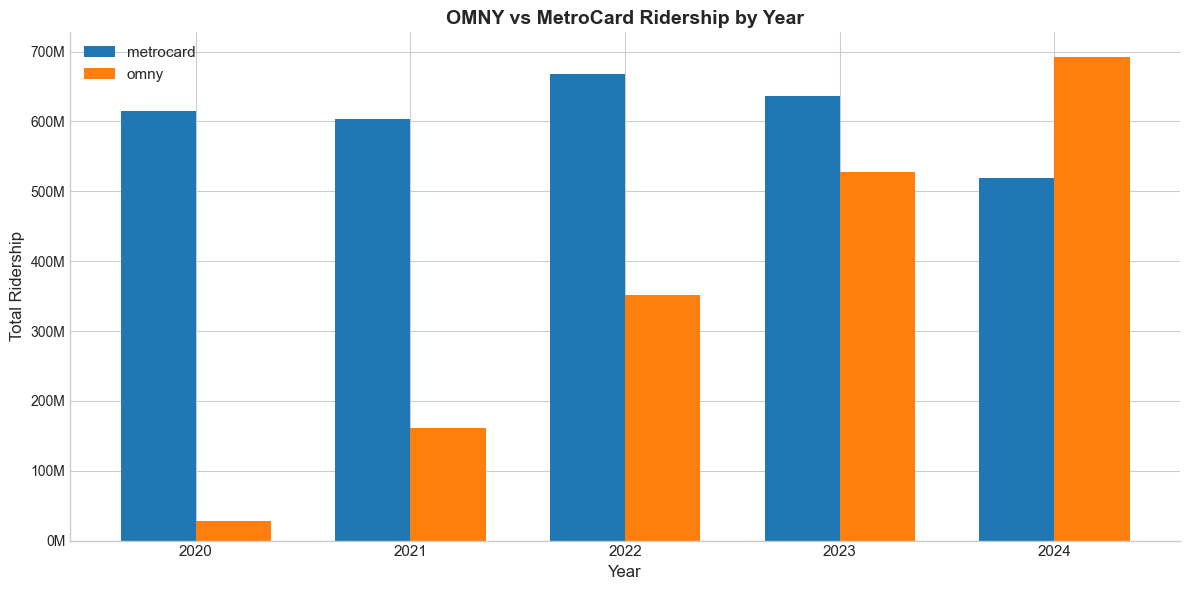

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

years = df_top_fare_risership['year'].unique()
payment_methods = df_top_fare_risership['payment_method'].unique()

x = np.arange(len(years))  # the label locations
width = 0.35  # the width of the bars

# MTA authentic colors
colors = {
    "OMNY":       "#0039A6",  # A/C/E blue
    "MetroCard":  "#FF6319"   # B/D/F/M orange
}

for i, method in enumerate(payment_methods):
    subset = df_top_fare_risership[df_top_fare_risership["payment_method"] == method]
    offset = (i - 0.5) * width
    bars = ax.bar(
        x + offset,
        subset["total_ridership"],
        width,
        label=method,
        color=colors.get(method)
    )

ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Ridership", fontsize=12)
ax.set_title("OMNY vs MetroCard Ridership by Year", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../report/figures/omny_vs_metrocard.png", dpi=150, bbox_inches="tight")
plt.show()

# Question 6 — Year-over-year COVID recovery

In [17]:
df_yearly_recovery = query("""
    SELECT
        strftime('%Y', transit_timestamp) AS year,
        SUM(ridership) AS total_ridership,
        ROUND(AVG(ridership), 2) AS avg_hourly_ridershipst
    FROM ridership
    GROUP BY year
    ORDER BY year ASC
""")

df_yearly_recovery

,year,total_ridership,avg_hourly_ridershipst
0,2020,643310743,31.63
1,2021,763914621,32.81
2,2022,1020580103,41.43
3,2023,1163347897,45.47
4,2024,1211514143,44.85


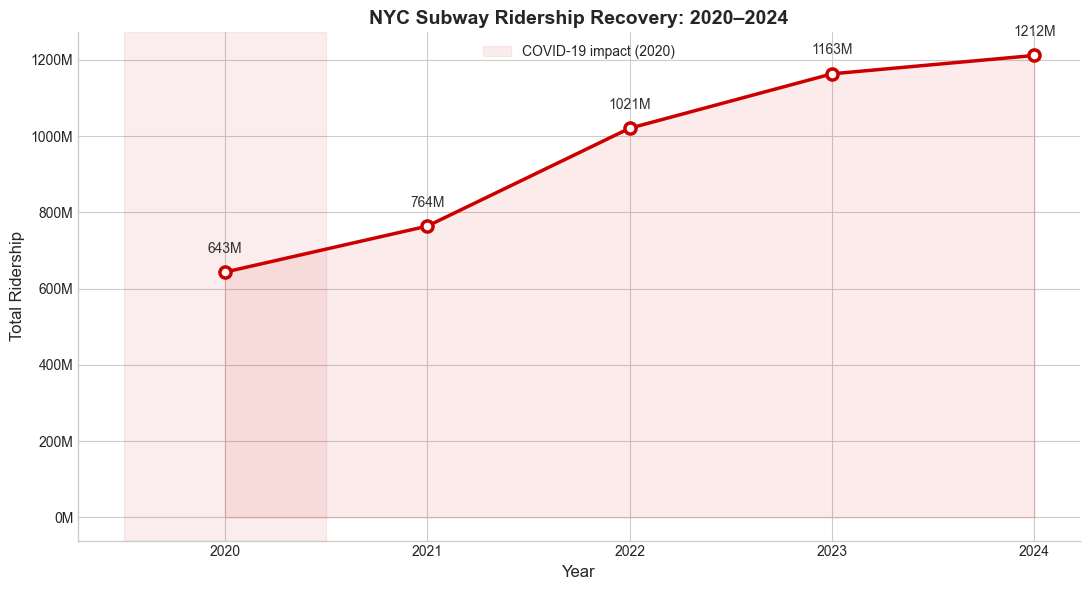

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))

years = df_yearly_recovery["year"].astype(str)
ridership = df_yearly_recovery["total_ridership"]

# Main recovery line
ax.plot(
    years,
    ridership,
    color="#CC0000",   # 1/2/3 subway red
    linewidth=2.5,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgecolor="#CC0000",
    markeredgewidth=2.5,
    zorder=3
)

# Shade the area under the curve
ax.fill_between(
    years,
    ridership,
    alpha=0.08,
    color="#CC0000"
)

# Annotate each point with its value
for x, y in zip(years, ridership):
    ax.annotate(
        f"{y/1e6:.0f}M",
        xy=(x, y),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        color="#333333"
    )

# Mark the COVID collapse year
ax.axvspan(
    -0.5, 0.5,       # shades the 2020 bar position
    alpha=0.07,
    color="#CC0000",
    label="COVID-19 impact (2020)"
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Ridership", fontsize=12)
ax.set_title("NYC Subway Ridership Recovery: 2020–2024",
             fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../report/figures/covid_recovery.png", dpi=150, bbox_inches="tight")
plt.show()